[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MarcoBattiato/PH6721-Deep-Learning-with-Python/blob/main/Classes/Class_2/02A-RegressionAndSupervisedLearning.ipynb)

# 02A — Regression and the Supervised Learning Framework
(by Marco Battiato. For questions/errors/bugs/typos report, please email at marco.battiato.teaching@gmail.com)

**PH6721 — Deep Learning with Python**
**Class 2, Notebook A — Hour 1**

**Instructor:** Marco Battiato (formerly Nanyang Assistant Professor @ Nanyang Technological University)

**email:**  marco.battiato.teaching@gmail.com

**In Person Classes:**  Wednesday 6:30pm - 9:45pm ()

**Consultation:** remote consultations are to be arranged by writing to marco.battiato.teaching@gmail.com

In the previous class we learned to load, summarise and visualise data.

We could *describe* a dataset, but we could not *predict* anything from it.

This notebook makes that step. It introduces the supervised learning framework that underlies
almost everything in the rest of the course, and then works through its simplest instance:
fitting a straight line to measurements.

The straight line is deliberately simple. The framework around it is not, and it is the part
worth learning carefully.

## Learning Objectives

By the end of this notebook, students should be able to:

- state the supervised learning problem in terms of features, targets, a model and a loss function;
- explain what "fitting a model" means as an optimization problem;
- fit a linear regression by least squares, using NumPy and scikit-learn;
- interpret regression coefficients, including their physical units;
- use residual plots to diagnose whether a model is adequate;
- extend linear regression to several features;
- explain why squared error is the natural loss under Gaussian noise;
- recognise situations where linear regression is the wrong tool.

# 1. From describing data to predicting

In notebook `01C` we asked questions such as:

- What does this dataset contain?
- How are the variables distributed?
- Which variables are related?

These are **descriptive** questions. They are about the data we already have.

Now we ask a different kind of question:

> Given the measurements we have collected, can we predict the value of some quantity for a **new** observation we have not seen?

This is a **predictive** question, and it is the subject of supervised learning.

The shift matters more than it may appear. A description only has to be faithful to the data in
front of us. A prediction has to be right about data that does not exist yet.

# 2. The supervised learning framework

Nearly every supervised method in this course fits the same template. Learning the template once
means that later methods differ only in their details.

## 2.1 Features and targets

We have $n$ observations. For each observation $i$ we have:

- a vector of **features** (also called inputs, predictors, or covariates)

$$
\mathbf{x}_i = (x_{i1}, x_{i2}, \ldots, x_{ip})
$$

- a **target** (also called the label, output, or response)

$$
y_i
$$

In the language of notebook `01C`: features are the columns we measure, and the target is the
column we want to predict.

The whole dataset is written as a matrix $\mathbf{X}$ of shape $(n, p)$ and a vector
$\mathbf{y}$ of length $n$.

Two distinct problems are covered by this notation:

| Target type | Problem | Example |
|---|---|---|
| Continuous number | **Regression** | Predict a material's band gap |
| Category | **Classification** | Predict which species a flower belongs to |

This notebook is about regression. The next notebook, `02B`, is about classification.

## 2.2 What a model is

A **model** is a family of functions, indexed by parameters $\boldsymbol{\theta}$:

$$
f_{\boldsymbol{\theta}} : \mathbf{x} \mapsto \hat{y}
$$

Choosing a model means choosing what shapes of relationship we are willing to consider.

For a straight line through one feature, the parameters are a slope and an intercept:

$$
f_{\boldsymbol{\theta}}(x) = \theta_1 x + \theta_0
$$

This is a very restrictive family. It contains every straight line, and nothing else. If the true
relationship is curved, no choice of $\theta_0$ and $\theta_1$ will represent it.

That restriction is the model's **inductive bias**, the idea introduced in notebook `01A`.

## 2.3 What a loss function is

Given parameters, we need a number saying how badly the model fits the data.

That number is the **loss**. For regression, the standard choice is the **mean squared error**:

$$
L(\boldsymbol{\theta}) = \frac{1}{n} \sum_{i=1}^{n} \bigl(y_i - f_{\boldsymbol{\theta}}(\mathbf{x}_i)\bigr)^2
$$

Each term measures how far the prediction is from the observed value. Squaring makes the errors
positive and penalises large errors disproportionately.

Section 9 explains why squaring specifically, rather than taking absolute values.

## 2.4 Training is optimization

**Training** or **fitting** a model means searching for the parameters that make the loss small:

$$
\hat{\boldsymbol{\theta}} = \arg\min_{\boldsymbol{\theta}} \; L(\boldsymbol{\theta})
$$

That is the entire idea. Every supervised method in this course is some version of:

1. choose a family of functions;
2. choose a loss that measures misfit;
3. search for the parameters minimising that loss.

Linear regression is the case where all three steps have a clean answer. Neural networks, in
Class 7, use the same three steps, but the search must be done numerically.

There is a fourth step, and it is the one beginners skip:

4. check whether the fitted model is any good **on data it was not fitted to**.

Class 3 is devoted entirely to step 4.

The four steps form a loop, and it is worth having the picture in mind because every supervised
method in this course is some traversal of it.

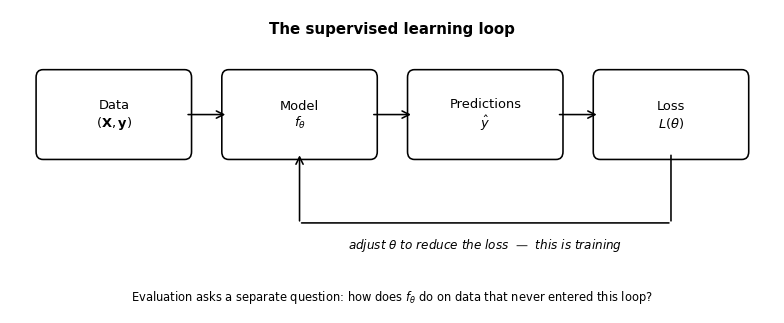

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(11, 4.6))

boxes = [
    (0.3,  2.0, "Data\n$(\\mathbf{X}, \\mathbf{y})$"),
    (3.0,  2.0, "Model\n$f_{\\theta}$"),
    (5.7,  2.0, "Predictions\n$\\hat{y}$"),
    (8.4,  2.0, "Loss\n$L(\\theta)$"),
]
w, h = 2.1, 1.0

for x, y, label in boxes:
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08,rounding_size=0.1",
                                linewidth=1.6, facecolor="white", edgecolor="black"))
    ax.text(x + w/2, y + h/2, label, ha="center", va="center", fontsize=13)

for i in range(len(boxes) - 1):
    ax.add_patch(FancyArrowPatch((boxes[i][0] + w, 2.5), (boxes[i+1][0], 2.5),
                                 arrowstyle="->", mutation_scale=18, linewidth=1.6))

# the feedback edge: adjust the parameters and go round again
ax.add_patch(FancyArrowPatch((9.45, 2.0), (9.45, 1.1), arrowstyle="-", mutation_scale=16, linewidth=1.6))
ax.add_patch(FancyArrowPatch((9.45, 1.1), (4.05, 1.1), arrowstyle="-", mutation_scale=16, linewidth=1.6))
ax.add_patch(FancyArrowPatch((4.05, 1.1), (4.05, 2.0), arrowstyle="->", mutation_scale=18, linewidth=1.6))
ax.text(6.75, 0.82, r"adjust $\theta$ to reduce the loss  —  this is training",
        ha="center", va="center", fontsize=12, style="italic")

ax.text(5.4, 3.55, "The supervised learning loop", ha="center", fontsize=15, fontweight="bold")
ax.text(5.4, 0.15, "Evaluation asks a separate question: how does $f_{\\theta}$ do on data that never entered this loop?",
        ha="center", va="center", fontsize=11.5)

ax.set_xlim(-0.2, 11.0); ax.set_ylim(-0.1, 3.9); ax.axis("off")
plt.tight_layout()
plt.show()

Only two boxes change from method to method. The **model** box becomes a tree, a support vector
machine or a neural network; the **loss** box changes when the target is a category rather than a
number. The shape of the loop does not change at all.

# 3. A first regression problem: measuring a spring constant

Let us work with a concrete physical measurement rather than an abstract dataset.

We hang a series of known forces from a spring and measure how far it extends.

Hooke's law says extension is proportional to applied force:

$$
x = \frac{F}{k}
$$

where $k$ is the spring constant we want to determine.

Two things complicate the measurement:

- each reading has **random error**: the scale is coarse, it is read by eye, and the spring
  takes a moment to settle;
- the ruler has a **zero offset**, because it was not aligned perfectly with the unstretched spring.

The second point is why we fit an intercept as well as a slope.

## 3.1 Simulating the measurements

We generate synthetic data so that we know the true answer and can check whether our method
recovers it. This is a good habit: before trusting a method on real data, test it on data whose
answer you already know.

The true values used below are a spring constant of $25$ N/m and a zero offset of $0.4$ cm.

Working in centimetres, Hooke's law becomes

$$
x_{\text{cm}} = \frac{100}{k} F + x_0
$$

so the true slope is $100/25 = 4$ cm/N and the true intercept is $0.4$ cm.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# --- Ground truth, which in a real experiment we would not know ---
k_true = 25.0        # spring constant, N/m
offset_true = 0.4    # ruler zero offset, cm
noise_std = 0.6      # reading error, cm

# --- The experiment: 12 known forces ---
force = np.linspace(0.5, 5.0, 12)                    # N

extension = (100.0 / k_true) * force + offset_true   # cm, exact
extension = extension + rng.normal(0, noise_std, size=force.shape)   # plus reading error

for f, x in zip(force, extension):
    print(f"  F = {f:4.2f} N    x = {x:5.2f} cm")

  F = 0.50 N    x =  2.58 cm
  F = 0.91 N    x =  3.41 cm
  F = 1.32 N    x =  6.12 cm
  F = 1.73 N    x =  7.87 cm
  F = 2.14 N    x =  7.77 cm
  F = 2.55 N    x =  9.80 cm
  F = 2.95 N    x = 12.29 cm
  F = 3.36 N    x = 13.66 cm
  F = 3.77 N    x = 15.48 cm
  F = 4.18 N    x = 16.62 cm
  F = 4.59 N    x = 19.29 cm
  F = 5.00 N    x = 20.87 cm


## 3.2 Look at the data first

The habit from notebook `01C` applies here too. Before fitting anything, plot the data.

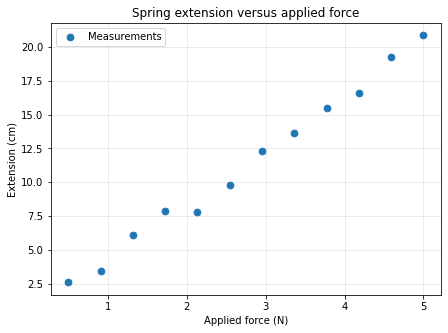

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(force, extension, s=45, zorder=3, label="Measurements")

plt.xlabel("Applied force (N)")
plt.ylabel("Extension (cm)")
plt.title("Spring extension versus applied force")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

The points lie close to a straight line, so a linear model is a reasonable choice here.

Notice that we made this judgement **by looking**, before choosing a model. That ordering is not
a formality; it is what prevents us from fitting a straight line to something curved.

# 4. Fitting a straight line

## 4.1 The model

Our model has two parameters:

$$
\hat{x} = a F + b
$$

where $a$ is the slope in cm/N and $b$ is the intercept in cm.

We want the values of $a$ and $b$ that make the predictions closest to the measurements.

## 4.2 Measuring how wrong a given line is

Let us first write the loss explicitly, as a function we can evaluate for any candidate line.

In [ ]:
def mse(a, b, x_data, y_data):
    """Mean squared error of the line y = a*x + b on the given data."""
    predictions = a * x_data + b
    residuals = y_data - predictions
    return np.mean(residuals ** 2)


# Try three candidate lines, none of them fitted
for a, b in [(3.0, 0.0), (4.0, 0.4), (5.0, 1.0)]:
    print(f"  a = {a:.1f}, b = {b:.1f}   ->   MSE = {mse(a, b, force, extension):.4f}")

  a = 3.0, b = 0.0   ->   MSE = 11.9540
  a = 4.0, b = 0.4   ->   MSE = 0.3104
  a = 5.0, b = 1.0   ->   MSE = 13.8344


Those three numbers are easier to trust once you can see what they correspond to. The figure below
draws the same three candidate lines through the measurements, each labelled with its own loss.

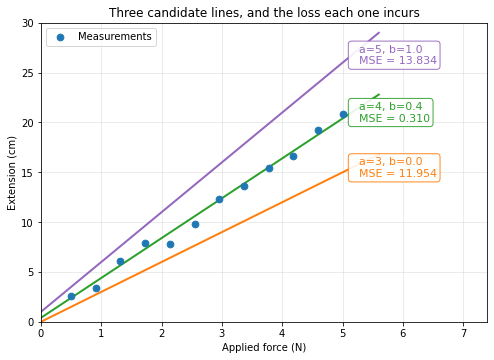

In [ ]:
candidates = [(3.0, 0.0), (4.0, 0.4), (5.0, 1.0)]
colours = ["tab:orange", "tab:green", "tab:purple"]

F_line = np.linspace(0, 5.6, 100)

plt.figure(figsize=(8, 5.5))
plt.scatter(force, extension, s=45, zorder=4, color="tab:blue", label="Measurements")

for (a, b), colour in zip(candidates, colours):
    plt.plot(F_line, a * F_line + b, color=colour, linewidth=2)

    # Put the loss on the line itself, at the right-hand end.
    x_label = 5.15
    plt.text(x_label, a * x_label + b, f"  a={a:.0f}, b={b:.1f}\n  MSE = {mse(a, b, force, extension):.3f}",
             color=colour, fontsize=11, va="center",
             bbox={"facecolor": "white", "edgecolor": colour, "boxstyle": "round,pad=0.3", "alpha": 0.9})

plt.xlabel("Applied force (N)")
plt.ylabel("Extension (cm)")
plt.title("Three candidate lines, and the loss each one incurs")
plt.xlim(0, 7.4)
plt.ylim(0, 30)
plt.grid(alpha=0.3)
plt.legend(loc="upper left")
plt.show()

The picture and the numbers say the same thing. The green line passes through the middle of the
measurements and its loss is about three tenths of a centimetre squared; the other two sit
visibly away from the data, and their losses are roughly forty times larger.

Notice also that the two poor lines have *similar* losses, around 12 and 14, despite one being too
shallow and the other too steep. The loss records how badly a line fits, not in which direction it
is wrong. That is why fitting needs a search over parameters, rather than a single correction.

The middle line, which happens to use the true parameter values, has by far the smallest loss.

This is the whole idea in miniature: the loss ranks candidate models, and fitting means finding
the best-ranked one.

## 4.3 The loss surface

Because we have only two parameters, we can draw the loss as a surface over all candidate
$(a, b)$ pairs and see the minimum directly.

This is a luxury. With a neural network's millions of parameters, no such picture is available,
which is why Class 7 must introduce gradient descent.

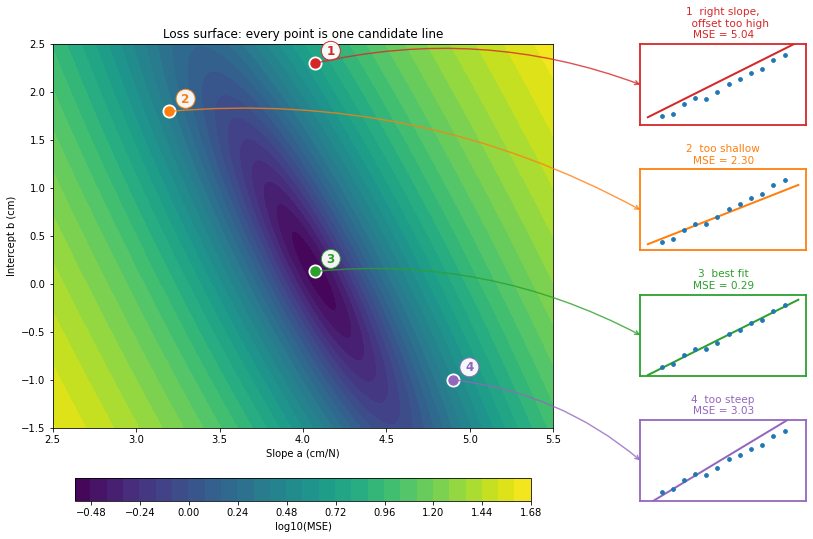

In [ ]:
from matplotlib.patches import ConnectionPatch

a_grid = np.linspace(2.5, 5.5, 200)
b_grid = np.linspace(-1.5, 2.5, 200)
A, B = np.meshgrid(a_grid, b_grid)

loss_surface = np.zeros_like(A)
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        loss_surface[i, j] = mse(A[i, j], B[i, j], force, extension)

# Four candidate parameter pairs to look at, one of them the best fit.
# Listed top to bottom by intercept, so the connecting arrows never cross.
probes = [
    (4.07,  2.30, "tab:red",    "1  right slope,\n    offset too high"),
    (3.20,  1.80, "tab:orange", "2  too shallow"),
    (4.07,  0.13, "tab:green",  "3  best fit"),
    (4.90, -1.00, "tab:purple", "4  too steep"),
]

fig = plt.figure(figsize=(13.5, 8.4))
gs = fig.add_gridspec(4, 3, width_ratios=[1.25, 1.25, 1.0], wspace=0.45, hspace=0.55)
ax_surf = fig.add_subplot(gs[:, 0:2])

contours = ax_surf.contourf(A, B, np.log10(loss_surface), levels=30, cmap="viridis")
fig.colorbar(contours, ax=ax_surf, orientation="horizontal", pad=0.11,
             label="log10(MSE)", fraction=0.05)
ax_surf.set_xlabel("Slope a (cm/N)")
ax_surf.set_ylabel("Intercept b (cm)")
ax_surf.set_title("Loss surface: every point is one candidate line")

F_line = np.linspace(0, 5.5, 50)

for row, (a, b, colour, label) in enumerate(probes):
    ax_surf.scatter([a], [b], s=150, color=colour, edgecolor="white", linewidth=1.8, zorder=5)
    ax_surf.annotate(label.split()[0], (a, b), textcoords="offset points", xytext=(12, 9),
                     fontsize=12, fontweight="bold", color=colour,
                     bbox={"facecolor": "white", "edgecolor": colour,
                           "boxstyle": "circle,pad=0.25", "alpha": 0.95})

    ax_p = fig.add_subplot(gs[row, 2])
    ax_p.scatter(force, extension, s=14, color="tab:blue", zorder=3)
    ax_p.plot(F_line, a * F_line + b, color=colour, linewidth=2)
    ax_p.set_ylim(0, 24)
    ax_p.set_xticks([]); ax_p.set_yticks([])
    ax_p.set_title(f"{label}\nMSE = {mse(a, b, force, extension):.2f}", fontsize=10.5, color=colour)
    for spine in ax_p.spines.values():
        spine.set_edgecolor(colour); spine.set_linewidth(1.8)

    # tie each panel to the point on the surface it corresponds to
    con = ConnectionPatch(xyA=(a, b), coordsA=ax_surf.transData,
                          xyB=(0, 0.5), coordsB=ax_p.transAxes,
                          arrowstyle="->", linewidth=1.4, color=colour,
                          connectionstyle="arc3,rad=-0.15", alpha=0.8)
    fig.add_artist(con)

plt.show()

Each of the four marked points is one candidate line, and the panel beside it shows what that
line actually looks like against the measurements. Walking downhill on the surface means moving
towards a line that passes through the data.

The surface has a single valley, and its floor is a smooth bowl.

This is a special and very convenient property: for linear regression with squared error, the
loss is a **convex** function of the parameters. There is exactly one minimum, and no local minima
to get trapped in.

Most models in this course do not have this property. Neural networks certainly do not.

Notice also that the valley is elongated and tilted. Slope and intercept are **correlated**: if we
increase the slope, we can partly compensate by decreasing the intercept. This is why the two
parameters cannot be determined independently of one another.

## 4.4 The least squares solution

For this model the minimum can be found exactly, by setting the derivatives of the loss with
respect to $a$ and $b$ to zero.

The result is the classical least squares solution:

$$
\hat{a} = \frac{\sum_i (F_i - \bar{F})(x_i - \bar{x})}{\sum_i (F_i - \bar{F})^2}
\qquad\qquad
\hat{b} = \bar{x} - \hat{a}\,\bar{F}
$$

Let us compute it directly, so that the formula is not a black box.

In [ ]:
F_mean = force.mean()
x_mean = extension.mean()

a_hat = np.sum((force - F_mean) * (extension - x_mean)) / np.sum((force - F_mean) ** 2)
b_hat = x_mean - a_hat * F_mean

print(f"Fitted slope     a = {a_hat:.4f} cm/N   (true {100/k_true:.4f})")
print(f"Fitted intercept b = {b_hat:.4f} cm     (true {offset_true:.4f})")
print(f"MSE at the fit       {mse(a_hat, b_hat, force, extension):.4f}")

Fitted slope     a = 4.0656 cm/N   (true 4.0000)
Fitted intercept b = 0.1345 cm     (true 0.4000)
MSE at the fit       0.2946


The fitted values are close to the true ones, but not identical.

They should not be identical. The measurements contain random error, so the best line through
*these particular* measurements is not exactly the true line. Repeating the experiment would give
slightly different estimates.

This distinction between the true parameter and our estimate of it runs through all of statistics
and machine learning.

It is worth seeing exactly what quantity was minimised. The vertical grey segments below are the
residuals: the gap between each measurement and the line's prediction at that force. Least squares
chooses the line making the **sum of the squares of these lengths** as small as possible.

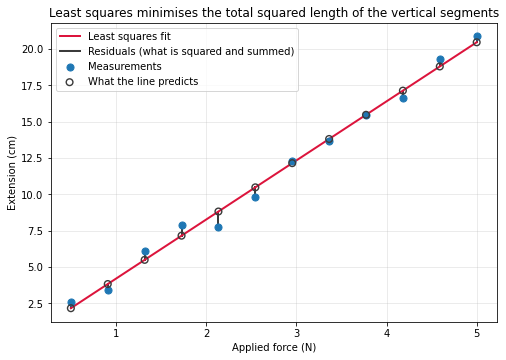

In [ ]:
predicted = a_hat * force + b_hat

plt.figure(figsize=(8, 5.5))

for f, obs, pred in zip(force, extension, predicted):
    plt.plot([f, f], [obs, pred], color="#3b3b3b", linewidth=2.0, zorder=2)

plt.scatter(force, extension, s=50, zorder=4, label="Measurements")
plt.scatter(force, predicted, s=45, facecolors="none", edgecolors="#3b3b3b",
            linewidth=1.4, zorder=5, label="What the line predicts")
plt.plot(force, predicted, color="crimson", linewidth=2, zorder=3, label="Least squares fit")
plt.plot([], [], color="#3b3b3b", linewidth=2.0, label="Residuals (what is squared and summed)")

plt.xlabel("Applied force (N)")
plt.ylabel("Extension (cm)")
plt.title("Least squares minimises the total squared length of the vertical segments")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Two details are worth noticing. The segments are **vertical**, not perpendicular to the line: the
method assumes the error is in the measured extension, not in the applied force. And some segments
point up while others point down — squaring is what stops them cancelling.

# 5. The same fit with NumPy and scikit-learn

In practice we do not implement least squares by hand. Two standard routes are available.

## 5.1 NumPy

`np.polyfit(x, y, deg)` fits a polynomial of the given degree. Degree 1 is a straight line.

It returns the coefficients in order of decreasing power, so for a line the slope comes first.

In [ ]:
coefficients = np.polyfit(force, extension, 1)
print("np.polyfit ->", coefficients)

slope_np, intercept_np = coefficients
print(f"  slope     {slope_np:.4f} cm/N")
print(f"  intercept {intercept_np:.4f} cm")

np.polyfit -> [4.06564802 0.13454178]
  slope     4.0656 cm/N
  intercept 0.1345 cm


## 5.2 scikit-learn

`scikit-learn` is the standard machine learning library for Python, and we will use it throughout
the course. Its interface is worth learning properly now, because every model in the library uses
the same one.

The pattern is always:

```python
model = SomeModel(...)      # 1. create, with any settings
model.fit(X, y)             # 2. fit to training data
predictions = model.predict(X_new)   # 3. predict on new data
```

One detail catches everyone the first time: `X` must be **two-dimensional**, of shape
`(n_samples, n_features)`, even when there is only one feature.

Our `force` array has shape `(12,)`. We reshape it to `(12, 1)`.

In [ ]:
from sklearn.linear_model import LinearRegression

X = force.reshape(-1, 1)     # shape (12, 1): 12 samples, 1 feature
y = extension                # shape (12,)

print("X shape:", X.shape)
print("y shape:", y.shape)

model = LinearRegression()
model.fit(X, y)

print(f"\nslope     {model.coef_[0]:.4f} cm/N")
print(f"intercept {model.intercept_:.4f} cm")

X shape: (12, 1)
y shape: (12,)

slope     4.0656 cm/N
intercept 0.1345 cm


All three routes, the explicit formula, `np.polyfit` and `scikit-learn`, give the same answer.

They are solving the same optimization problem. The difference is only convenience.

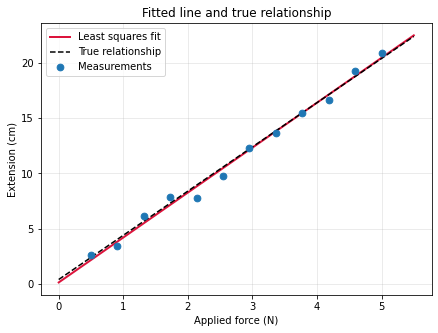

In [ ]:
F_line = np.linspace(0, 5.5, 100)
x_line = model.predict(F_line.reshape(-1, 1))

plt.figure(figsize=(7, 5))
plt.scatter(force, extension, s=45, zorder=3, label="Measurements")
plt.plot(F_line, x_line, color="crimson", linewidth=2, label="Least squares fit")
plt.plot(F_line, (100 / k_true) * F_line + offset_true, "k--",
         linewidth=1.5, label="True relationship")

plt.xlabel("Applied force (N)")
plt.ylabel("Extension (cm)")
plt.title("Fitted line and true relationship")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

<div class="alert alert-success">
<b>Mini-exercise 1 — Fitting a line</b><br>
1. Change the random seed in Section 3.1 and re-run the fit. How much do the fitted slope and intercept change?<br>
2. Increase <code>noise_std</code> to <code>0.5</code>. What happens to the estimates?<br>
3. Reduce the number of measurements from 12 to 4. What happens?<br>
4. Based on these experiments, what two things make a fitted parameter more reliable?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 6. Interpreting the fit

A fitted model is not just a prediction machine. In scientific work, the parameters usually mean
something.

## 6.1 Coefficients carry units

Our slope is measured in cm/N, because it converts a force into an extension.

From Hooke's law, the slope equals $100/k$, so we can recover the spring constant:

$$
k = \frac{100}{\hat{a}}
$$

In [ ]:
k_estimated = 100.0 / model.coef_[0]

print(f"Estimated spring constant: {k_estimated:.2f} N/m")
print(f"True spring constant:      {k_true:.2f} N/m")
print(f"Relative error:            {100 * abs(k_estimated - k_true) / k_true:.1f} %")

Estimated spring constant: 24.60 N/m
True spring constant:      25.00 N/m
Relative error:            1.6 %


This is what regression is doing in a great deal of experimental science: it is **parameter
estimation**. The line itself is of no interest. The physical constant extracted from its slope is.

The intercept is also informative. It estimates the ruler's zero offset, a systematic error of the
apparatus. Had we forced the line through the origin, that error would have contaminated the slope
and biased our estimate of $k$.

## 6.2 A warning about interpretation

Coefficients are interpretable here because we have a physical model telling us what they mean.

Without such a model, interpretation is much more delicate. In Section 8 we will fit a model with
ten features, and there the coefficients will *not* support a simple causal reading.

# 7. Residuals: the most useful diagnostic

## 7.1 What residuals are

The **residual** of observation $i$ is the part the model failed to explain:

$$
r_i = y_i - \hat{y}_i
$$

A single summary number such as the MSE tells us how large the residuals are on average.

Plotting the residuals tells us something more valuable: **whether they have structure**.

## 7.2 Good residuals look like noise

If the model is adequate, the residuals should look like random scatter about zero, with no
visible pattern as the input varies.

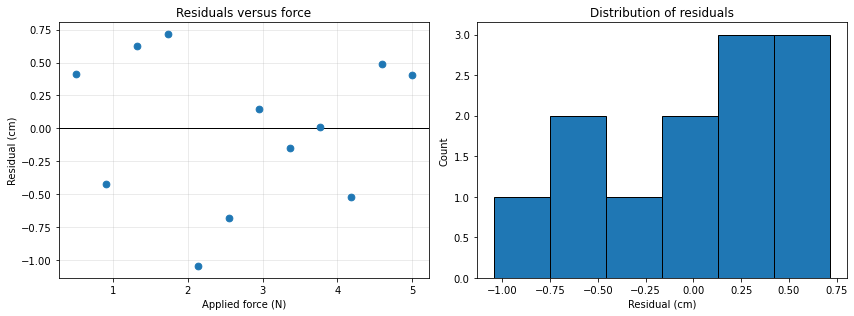

Mean residual:               3.70e-16 cm
Std of residuals:            0.595 cm
Assumed measurement error:   0.600 cm


In [ ]:
predictions = model.predict(X)
residuals = extension - predictions

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(force, residuals, s=45, zorder=3)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xlabel("Applied force (N)")
axes[0].set_ylabel("Residual (cm)")
axes[0].set_title("Residuals versus force")
axes[0].grid(alpha=0.3)

axes[1].hist(residuals, bins=6, edgecolor="black")
axes[1].set_xlabel("Residual (cm)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of residuals")

plt.tight_layout()
plt.show()

print(f"Mean residual:               {residuals.mean():.2e} cm")
print(f"Std of residuals:            {residuals.std(ddof=2):.3f} cm")
print(f"Assumed measurement error:   {noise_std:.3f} cm")

Two observations.

First, the mean residual is essentially zero. This is not a coincidence or a sign of a good fit:
least squares with an intercept **always** produces residuals summing to zero. It tells us nothing.

Second, the spread of the residuals is close to the measurement error we put in. This *is*
informative. It says the model explains the data down to the level of the noise, and there is
nothing systematic left over.

Residual scatter that matches the known instrumental precision is about the best outcome an
experimentalist can hope for.

## 7.3 Bad residuals have structure

Now suppose we stretch the spring beyond its elastic limit, where Hooke's law stops holding and
the response becomes slightly nonlinear.

We will simulate that, fit a straight line anyway, and look at the residuals.

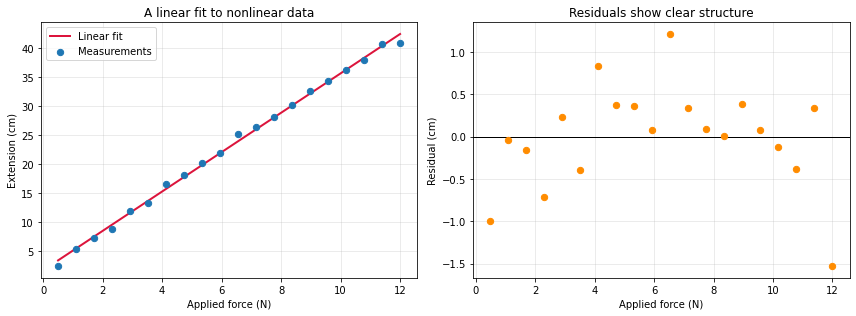

In [ ]:
force_wide = np.linspace(0.5, 12.0, 20)

# Hooke's law plus a small quadratic stiffening term
extension_nl = ((100.0 / k_true) * force_wide
                - 0.05 * force_wide ** 2
                + offset_true
                + rng.normal(0, noise_std, size=force_wide.shape))

model_nl = LinearRegression().fit(force_wide.reshape(-1, 1), extension_nl)
residuals_nl = extension_nl - model_nl.predict(force_wide.reshape(-1, 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(force_wide, extension_nl, s=40, zorder=3, label="Measurements")
axes[0].plot(force_wide, model_nl.predict(force_wide.reshape(-1, 1)),
             color="crimson", linewidth=2, label="Linear fit")
axes[0].set_xlabel("Applied force (N)")
axes[0].set_ylabel("Extension (cm)")
axes[0].set_title("A linear fit to nonlinear data")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].scatter(force_wide, residuals_nl, s=40, zorder=3, color="darkorange")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xlabel("Applied force (N)")
axes[1].set_ylabel("Residual (cm)")
axes[1].set_title("Residuals show clear structure")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Look at the two panels carefully.

In the left panel the fit looks acceptable. The line passes through the data and nothing screams
that it is wrong.

In the right panel the failure is unmistakable. The residuals form a clean arc: negative at both
ends, positive in the middle. That curve is the part of the physics the straight line could not
capture.

This is why residual plots matter. A model can look fine in the fitted-line plot and still be
systematically wrong, and the residual plot is where that shows up.

> A pattern in the residuals means the model is missing something real.

Here, the missing thing is the nonlinearity of the spring at large extension, which is a physical
result about the material. The diagnostic is not merely statistical bookkeeping.

<div class="alert alert-success">
<b>Mini-exercise 2 — Reading residuals</b><br>
1. Change the coefficient of the quadratic term from <code>-0.05</code> to <code>-0.005</code>. Is the structure still visible in the residual plot? Is it visible in the fitted-line plot?<br>
2. Set the quadratic coefficient to <code>0.0</code>. What do the residuals look like now?<br>
3. Restrict the force range to <code>np.linspace(0.5, 4.0, 20)</code> with the original <code>-0.05</code> term. Can you still detect the nonlinearity?<br>
4. What does part 3 suggest about the range over which an experiment should be conducted?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

## 7.4 A single number that agrees with the wrong model

It is tempting to replace the residual plot with one summary number. The most common one for
regression is the **coefficient of determination**, written $R^2$.

It compares the model against the laziest possible predictor: always guessing the mean of the
target, ignoring the input entirely.

$$
R^2 \;=\; 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}
$$

The numerator is the squared error the model leaves behind; the denominator is the squared error
that guessing $\bar{y}$ would leave. So:

- $R^2 = 1$ — the model reproduces the data exactly;
- $R^2 = 0$ — the model is no better than guessing the mean;
- $R^2 < 0$ — the model is *worse* than guessing the mean, which is possible.

It is convenient because it is dimensionless: unlike the MSE, it does not change if you measure
extension in centimetres rather than metres.

Now let us compute it for both fits from this section.

In [ ]:
from sklearn.metrics import r2_score

# The good case: a straight line through the linear spring data
r2_linear = r2_score(extension, model.predict(X))

# The bad case from 7.3: a straight line through the *nonlinear* spring data
r2_nonlinear = r2_score(extension_nl, model_nl.predict(force_wide.reshape(-1, 1)))

print(f"straight line on linear data     R2 = {r2_linear:.4f}   <- correct model")
print(f"straight line on NONLINEAR data  R2 = {r2_nonlinear:.4f}   <- wrong model")

straight line on linear data     R2 = 0.9911   <- correct model
straight line on NONLINEAR data  R2 = 0.9975   <- wrong model


Read those two numbers again.

The **wrong** model scores *higher* than the right one. A straight line fitted to a spring that is
visibly not obeying Hooke's law achieves $R^2 = 0.9975$, while the correct model on well-behaved
data manages 0.9911.

Nothing has gone wrong with the arithmetic. $R^2$ measures how much of the variation in $y$ the
model accounts for, and over a wide force range a curved relationship still rises steeply, so a
straight line captures most of that variation. It says nothing at all about whether the *shape* is
right.

> A high $R^2$ tells you the model explains much of the variation. It does not tell you the model
> is correct.

The residual plot in section 7.3 caught this immediately, and no single number did. That is why
residuals come first in this notebook and $R^2$ comes second.

We will meet $R^2$ again in Class 3, alongside the other regression and classification metrics and
the question of how to choose between them.

# 8. Multiple linear regression

## 8.1 More than one feature

Real scientific problems rarely have a single input. The model generalises directly:

$$
\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_p x_p
$$

or compactly, $\hat{y} = \theta_0 + \boldsymbol{\theta}^\top \mathbf{x}$.

The geometry changes, a line becomes a plane and then a hyperplane, but nothing conceptual does.
The loss is still squared error, the solution is still least squares, and `scikit-learn` does not
even need a different class.

The only change in code is that `X` now has more than one column.

With one feature the model is a line in a plane. With two, it is a **plane** in a
three-dimensional space, with the target on the vertical axis. The picture below makes the claim
concrete before we return to real data.

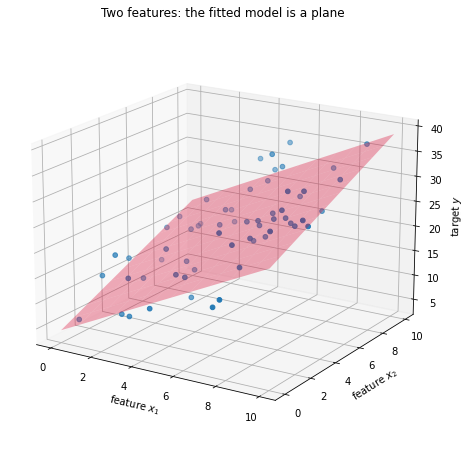

In [ ]:
from mpl_toolkits.mplot3d import Axes3D    # noqa: F401  (registers the 3d projection)

rng_demo = np.random.default_rng(3)
n_demo = 60
x1 = rng_demo.uniform(0, 10, n_demo)
x2 = rng_demo.uniform(0, 10, n_demo)
y_demo = 2.0 * x1 + 1.2 * x2 + 5.0 + rng_demo.normal(0, 4.0, n_demo)

model_3d = LinearRegression().fit(np.column_stack([x1, x2]), y_demo)

grid_1, grid_2 = np.meshgrid(np.linspace(0, 10, 12), np.linspace(0, 10, 12))
grid_y = (model_3d.intercept_
          + model_3d.coef_[0] * grid_1
          + model_3d.coef_[1] * grid_2)

fig = plt.figure(figsize=(9, 6.5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(grid_1, grid_2, grid_y, alpha=0.35, color="crimson", edgecolor="none")
ax.scatter(x1, x2, y_demo, s=22, color="tab:blue", depthshade=True)

ax.set_xlabel("feature $x_1$")
ax.set_ylabel("feature $x_2$")
ax.set_zlabel("target $y$")
ax.set_title("Two features: the fitted model is a plane")
ax.view_init(elev=18, azim=-58)
plt.tight_layout()
plt.show()

Beyond two features the picture stops being drawable, but nothing else changes: with $p$ features
the model is a flat $p$-dimensional surface in a $(p+1)$-dimensional space, and least squares
still chooses the one closest to the data in the vertical direction.

## 8.2 A real dataset

We use the diabetes dataset bundled with `scikit-learn`. It contains ten physiological
measurements for 442 patients, and the target is a quantitative measure of disease progression one
year later.

The features have already been standardised by the dataset's authors, so each has mean zero.

In [ ]:
import pandas as pd
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True)
data = diabetes.frame

print("Shape:", data.shape)
print("\nColumns:", list(data.columns))
data.head()

Shape: (442, 11)

Columns: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019908,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068330,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005671,-0.045599,-0.034194,-0.032356,-0.002592,0.002864,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022692,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031991,-0.046641,135.0


Following the habit from `01C`, we look before we model.

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64


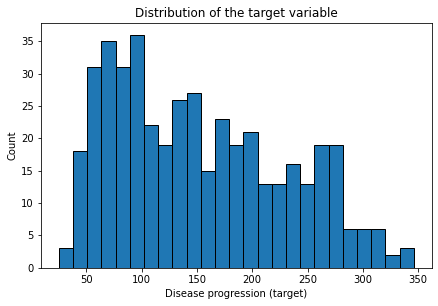

In [ ]:
feature_names = [c for c in data.columns if c != "target"]

X_all = data[feature_names]
y_all = data["target"]

print(y_all.describe())

plt.figure(figsize=(7, 4.5))
plt.hist(y_all, bins=25, edgecolor="black")
plt.xlabel("Disease progression (target)")
plt.ylabel("Count")
plt.title("Distribution of the target variable")
plt.show()

## 8.3 Fitting one feature, then all ten

Let us first fit body mass index alone, then all ten features together, and compare.

We use $R^2$, defined in section 7.4, to summarise fit quality — remembering what it cannot tell
us.

In [ ]:
from sklearn.metrics import r2_score

# --- One feature ---
model_bmi = LinearRegression().fit(data[["bmi"]], y_all)
r2_bmi = r2_score(y_all, model_bmi.predict(data[["bmi"]]))

# --- All ten features ---
model_all = LinearRegression().fit(X_all, y_all)
r2_all = r2_score(y_all, model_all.predict(X_all))

print(f"R2 using bmi only:        {r2_bmi:.3f}")
print(f"R2 using all 10 features: {r2_all:.3f}")

R2 using bmi only:        0.344
R2 using all 10 features: 0.518


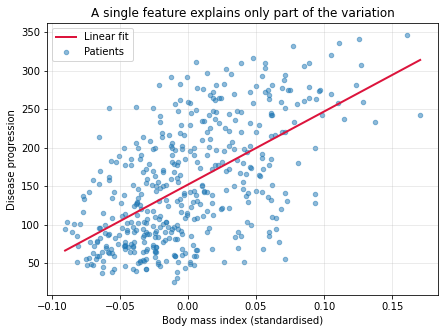

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(data["bmi"], y_all, s=20, alpha=0.5, label="Patients")

# Build the prediction inputs as a DataFrame with the same column name used for fitting.
# Passing a bare array here works, but scikit-learn warns about the missing feature name.
bmi_line = pd.DataFrame({"bmi": np.linspace(data["bmi"].min(), data["bmi"].max(), 100)})

plt.plot(bmi_line["bmi"], model_bmi.predict(bmi_line), color="crimson",
         linewidth=2, label="Linear fit")

plt.xlabel("Body mass index (standardised)")
plt.ylabel("Disease progression")
plt.title("A single feature explains only part of the variation")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Compare this scatter with the spring measurements in Section 3.2.

The spring data lay almost exactly on a line. Here the points form a broad cloud with a visible
upward trend. The relationship is real but weak, and no straight line will predict any individual
patient well.

This is much more typical of scientific and biomedical data than the spring example is.

## 8.4 Reading the coefficients

With standardised features, larger coefficients indicate features with more influence on the
prediction.

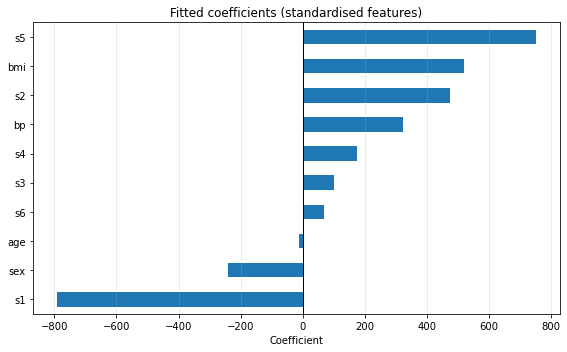

s1    -792.2
sex   -239.8
age    -10.0
s6      67.6
s3     101.0
s4     177.1
bp     324.4
s2     476.7
bmi    519.8
s5     751.3
dtype: float64


In [ ]:
coefficients = pd.Series(model_all.coef_, index=feature_names).sort_values()

plt.figure(figsize=(8, 5))
coefficients.plot(kind="barh")
plt.xlabel("Coefficient")
plt.title("Fitted coefficients (standardised features)")
plt.axvline(0, color="black", linewidth=1)
plt.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

print(coefficients.round(1))

It is tempting to read this chart as a ranking of causes. Resist that reading.

Several of these features are strongly correlated with one another. The pair `s1` and `s2` has a
correlation of about $0.90$, and there are several other pairs above $0.6$.

When features are correlated, the fit can distribute influence between them almost arbitrarily,
and individual coefficients become unstable: a small change in the data can swing a coefficient
from large positive to large negative.

Look at `s1` and `s2` in the chart. They are the most strongly correlated pair in the dataset, and
they carry large coefficients of **opposite sign**, roughly $-790$ and $+480$. The two features
move together almost in lockstep, so the model can add a large amount of one and subtract a large
amount of the other with little net effect on its predictions.

That is a signature of correlated features, not a discovery about physiology. Neither coefficient
should be read as "the effect of `s1`".

This is one motivation for the regularization methods in Class 3, and it is a specific instance of
the more general warning from `01C`:

> A fitted relationship is not a causal one.

<div class="alert alert-success">
<b>Mini-exercise 3 — Multiple regression</b><br>
1. Fit a linear regression using only <code>bmi</code> and <code>s5</code>. What <code>R2</code> do you obtain?<br>
2. Compute the correlation matrix of the ten features, using the method from <code>01C</code>. Which pairs are most strongly correlated?<br>
3. Fit the model on only the first 200 patients, then on only the last 200. Compare the coefficient for <code>s1</code> between the two fits.<br>
4. What does the comparison in part 3 tell you about how much to trust an individual coefficient?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 9. Why squared error?

Minimising the sum of squares can look arbitrary. Why not the sum of absolute errors?

There is a principled answer, and it connects regression to probability. This connection reappears
throughout the course, so it is worth seeing once properly.

Suppose the measurements are generated by a true relationship plus independent Gaussian noise:

$$
y_i = f_{\boldsymbol{\theta}}(\mathbf{x}_i) + \varepsilon_i,
\qquad \varepsilon_i \sim \mathcal{N}(0, \sigma^2)
$$

Then the probability of observing $y_i$ given the parameters is

$$
p(y_i \mid \mathbf{x}_i, \boldsymbol{\theta}) =
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\!\left(-\frac{(y_i - f_{\boldsymbol{\theta}}(\mathbf{x}_i))^2}{2\sigma^2}\right)
$$

Because the measurements are independent, the **likelihood** of the whole dataset is the product
of these terms. Taking a logarithm turns the product into a sum:

$$
\log p(\mathbf{y} \mid \mathbf{X}, \boldsymbol{\theta}) =
-\frac{1}{2\sigma^2} \sum_{i=1}^{n} \bigl(y_i - f_{\boldsymbol{\theta}}(\mathbf{x}_i)\bigr)^2
\;-\; \frac{n}{2}\log(2\pi\sigma^2)
$$

The second term does not depend on $\boldsymbol{\theta}$. So maximising the log-likelihood over
$\boldsymbol{\theta}$ is exactly minimising

$$
\sum_{i=1}^{n} \bigl(y_i - f_{\boldsymbol{\theta}}(\mathbf{x}_i)\bigr)^2
$$

which is the least squares criterion.

**Least squares is maximum likelihood estimation under Gaussian noise.**

Three consequences are worth stating.

First, the choice of loss encodes an assumption about the noise. It is not a neutral technical
detail.

Second, if the noise is *not* Gaussian, squared error may be a poor choice. Heavy-tailed noise, or
data containing outliers, corresponds to a different distribution and calls for a different loss.
Minimising absolute error is the maximum likelihood solution under Laplace-distributed noise, and
it is far less sensitive to outliers.

Third, this same argument, applied to a categorical target instead of a continuous one, produces
the cross-entropy loss used for classification. That is the subject of notebook `02B`.

The figure below is the same statement drawn. At each force, the model predicts one extension, and
the assumption is that the actual reading is drawn from a bell curve centred on that prediction.
Maximising the likelihood means choosing the line under which the readings we actually got are
the least surprising.

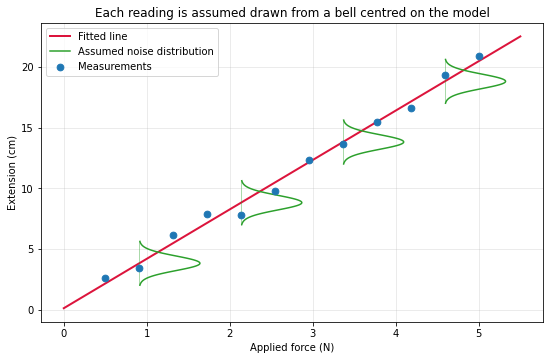

In [ ]:
from scipy.stats import norm

plt.figure(figsize=(9, 5.5))

F_line = np.linspace(0, 5.5, 100)
plt.plot(F_line, a_hat * F_line + b_hat, color="crimson", linewidth=2, label="Fitted line")

# a bell curve, on its side, at four of the measured forces
for idx in [1, 4, 7, 10]:
    f = force[idx]
    centre = a_hat * f + b_hat
    span = np.linspace(centre - 3*noise_std, centre + 3*noise_std, 100)
    density = norm.pdf(span, centre, noise_std)
    plt.plot(f + density * 1.1, span, color="tab:green", linewidth=1.5)
    plt.plot([f, f], [span[0], span[-1]], color="tab:green", linewidth=0.8, alpha=0.5)

plt.scatter(force, extension, s=45, zorder=4, label="Measurements")
plt.plot([], [], color="tab:green", linewidth=1.5, label="Assumed noise distribution")

plt.xlabel("Applied force (N)")
plt.ylabel("Extension (cm)")
plt.title("Each reading is assumed drawn from a bell centred on the model")
plt.grid(alpha=0.3)
plt.legend(loc="upper left")
plt.show()

The choice of loss follows from the shape of that bell. Squared error comes from a Gaussian;
absolute error comes from a heavier-tailed distribution. The difference is visible directly in how
the two losses grow.

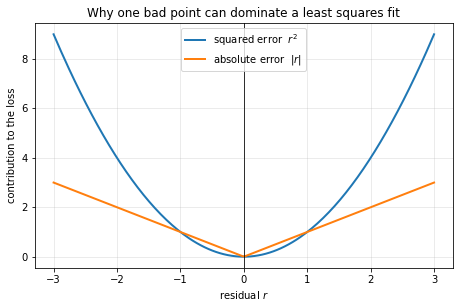

In [ ]:
r = np.linspace(-3, 3, 200)

plt.figure(figsize=(7.5, 4.5))
plt.plot(r, r**2, linewidth=2, label="squared error  $r^2$")
plt.plot(r, np.abs(r), linewidth=2, label="absolute error  $|r|$")

plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("residual $r$")
plt.ylabel("contribution to the loss")
plt.title("Why one bad point can dominate a least squares fit")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

At a residual of 1 the two agree. At a residual of 3 the squared error contributes nine, against
three for the absolute error. A single badly misread value therefore counts for far more under
squared error, which is exactly what the next cell demonstrates.

The sensitivity to outliers is easy to demonstrate. We corrupt a single measurement by 3 cm, as if
one ruler reading had been badly misread, and refit.

We do this twice: once corrupting a point in the **middle** of the force range, and once
corrupting a point at the **end**. The difference between the two is instructive.

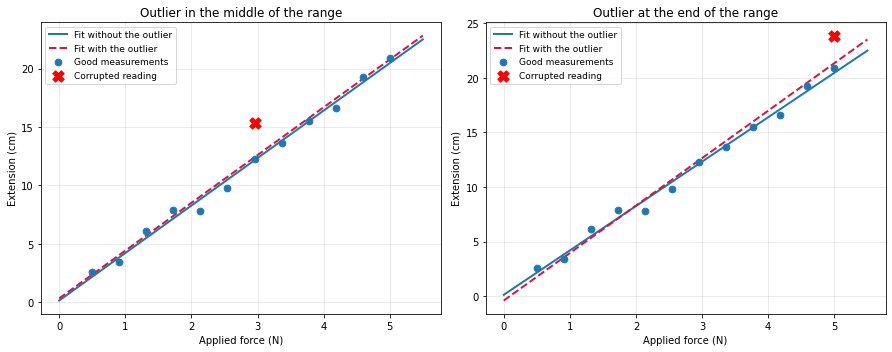

True spring constant:            25.00 N/m
Clean data:                      24.60 N/m
Outlier in the middle:           24.44 N/m
Outlier at the end:              23.00 N/m


In [ ]:
model_clean = LinearRegression().fit(X, extension)

# Corrupt a middle point, then an end point
extension_mid = extension.copy()
extension_mid[6] += 3.0

extension_end = extension.copy()
extension_end[11] += 3.0

model_mid = LinearRegression().fit(X, extension_mid)
model_end = LinearRegression().fit(X, extension_end)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))

for ax, corrupted, model_c, idx, title in [
    (axes[0], extension_mid, model_mid, 6, "Outlier in the middle of the range"),
    (axes[1], extension_end, model_end, 11, "Outlier at the end of the range"),
]:
    ax.scatter(force, extension, s=45, zorder=3, label="Good measurements")
    ax.scatter(force[idx], corrupted[idx], s=130, color="red",
               marker="X", zorder=4, label="Corrupted reading")
    ax.plot(F_line, model_clean.predict(F_line.reshape(-1, 1)),
            linewidth=2, label="Fit without the outlier")
    ax.plot(F_line, model_c.predict(F_line.reshape(-1, 1)),
            linewidth=2, linestyle="--", color="crimson", label="Fit with the outlier")
    ax.set_xlabel("Applied force (N)")
    ax.set_ylabel("Extension (cm)")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"True spring constant:            {k_true:.2f} N/m")
print(f"Clean data:                      {100 / model_clean.coef_[0]:.2f} N/m")
print(f"Outlier in the middle:           {100 / model_mid.coef_[0]:.2f} N/m")
print(f"Outlier at the end:              {100 / model_end.coef_[0]:.2f} N/m")

The two panels behave very differently, and the printed numbers make it precise.

The **middle** outlier barely changes the estimated spring constant, moving it by well under one
percent. The fitted line shifts upwards a little, but its slope is almost untouched: the corrupted
point pulls the line up without any reason to tilt it.

The **end** outlier changes the slope substantially, shifting the estimated spring constant by
several percent. A point far from the mean of the inputs acts on the slope with a long lever arm.

This property is called **leverage**. An observation's influence on a fit depends not only on how
wrong it is, but on **where** it sits in the input range. Points at the extremes of the range carry
the most influence.

The squaring is what makes outliers matter at all: an error three times larger contributes nine
times more to the loss, so the fit bends towards the outlier to reduce it. Leverage determines
*how* it bends.

Both effects follow from the Gaussian assumption, and both are reasons to inspect data for
outliers before fitting, exactly as `01C` recommended, and to be especially careful about
suspicious points at the edges of the measured range.

# 10. When linear regression is the wrong tool

Linear regression is the right first thing to try in many situations, and a poor choice in others.

**It is a good choice when:**

- theory predicts a linear relationship, as with Hooke's law;
- the aim is to estimate a physically meaningful parameter;
- the dataset is small and interpretability matters;
- a simple, reliable baseline is needed before trying anything complicated.

**It is a poor choice when:**

- the relationship is genuinely nonlinear, as Section 7.3 showed;
- the features interact, so that the effect of one depends on another;
- the data contain many outliers;
- the input is an image, a sequence, a graph, or text.

That last case is worth stating clearly. Later classes are largely about inputs for which the very
notion of a linear coefficient per input variable makes no sense. A pixel intensity at position
$(37, 42)$ is not a scientific variable with a stable meaning across images.

It is also worth saying that "linear" is less restrictive than it appears. Linear regression is
linear **in the parameters**, not necessarily in the inputs. Fitting

$$
\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2 + \theta_3 x^3
$$

is still a linear regression problem, because the parameters enter linearly. We simply construct
new features $x, x^2, x^3$ and fit as before.

This idea, **basis expansion**, is how we will fix the nonlinear spring in Class 3, and it leads
directly to the discussion of overfitting.

<div class="alert alert-success">
<b>Mini-exercise 4 — A first basis expansion</b><br>
Return to the nonlinear spring data from Section 7.3.
<br><br>
1. Build a feature matrix with two columns, <code>force_wide</code> and <code>force_wide ** 2</code>. Hint: <code>np.column_stack</code>.<br>
2. Fit a <code>LinearRegression</code> to it.<br>
3. Plot the fitted curve over the data, and plot the residuals.<br>
4. Compare with the straight-line residuals in Section 7.3. Has the arc disappeared?<br>
5. Compare the fitted coefficient of the quadratic term with the value <code>-0.05</code> used to generate the data.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 11. Common pitfalls

**Fitting before plotting.**
A straight line can be fitted to anything. Whether it *should* be is a question the scatter plot
answers and the fitting routine does not.

**Judging a fit by $R^2$ alone.**
A high $R^2$ does not mean the model is correct, and a low one does not mean it is useless. In
section 7.4 the straight line fitted to the *nonlinear* spring scored $R^2 = 0.9975$, beating the
correct model on well-behaved data. Look at the residuals.

**Never looking at residuals.**
This is where systematic error becomes visible, and it costs one line of code.

**Forcing the line through the origin because theory says it should pass through it.**
Theory describes the physics; the intercept absorbs offsets in the *apparatus*. Removing it
transfers instrumental error into the slope, which is usually the quantity of interest.

**Reading coefficients causally.**
Especially with correlated features, where individual coefficients can be unstable and even change
sign, as Section 8.4 showed.

**Extrapolating beyond the fitted range.**
The spring obeyed Hooke's law up to 5 N and not at 12 N. A model is evidence only about the region
where data were collected.

**Forgetting that `X` must be two-dimensional in scikit-learn.**
Shape `(n,)` and shape `(n, 1)` are different, as notebook `01B` warned.

**Evaluating on the same data used for fitting.**
Every number computed in this notebook was measured on the training data. That is acceptable here
because our models had two parameters and no capacity to memorise. It stops being acceptable very
quickly, and Class 3 explains why.

# 12. Final exercises

<div class="alert alert-success">
<b>Exercise 1 — A calibration experiment</b><br>
A thermocouple produces a voltage that depends on temperature. You have the following calibration data:
<br><br>
<code>temperature = np.array([0, 20, 40, 60, 80, 100, 120, 140, 160, 180])</code>  # °C<br>
<code>voltage = np.array([0.02, 0.81, 1.63, 2.38, 3.24, 4.01, 4.83, 5.59, 6.44, 7.19])</code>  # mV
<br><br>
1. Plot the data.<br>
2. Fit a straight line and report the slope with its units.<br>
3. Plot the residuals. Is a linear calibration adequate?<br>
4. Use the fitted model to estimate the temperature corresponding to a reading of 3.00 mV.<br>
5. Would you trust the model at 400 °C? Explain.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 2 — Noise, sample size and reliability</b><br>
Write a small numerical experiment that investigates how reliably the spring constant is recovered.
<br><br>
1. Write a function that generates a synthetic spring dataset with given <code>n_points</code> and <code>noise_std</code>, fits a line, and returns the estimated <code>k</code>.<br>
2. Run it 200 times for <code>n_points = 12</code> and <code>noise_std = 0.15</code>. Plot a histogram of the estimates.<br>
3. Repeat for <code>n_points = 100</code>. How does the histogram change?<br>
4. Repeat for <code>noise_std = 0.5</code> with <code>n_points = 12</code>.<br>
5. State in one sentence how the spread of the estimates depends on the number of measurements and on the measurement error.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 3 — Choosing a model honestly</b><br>
Using the diabetes dataset from Section 8:
<br><br>
1. Fit linear regressions using 1, 2, 5 and then all 10 features, and record the <code>R2</code> of each.<br>
2. Plot <code>R2</code> against the number of features.<br>
3. Does <code>R2</code> ever decrease when a feature is added? Explain why not.<br>
4. Given part 3, explain why <code>R2</code> measured on the training data cannot be used to choose how many features to include.
<br><br>
Part 4 is the question Class 3 is built around, so it is worth thinking about before you get there.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# Key Takeaways

- Supervised learning has four parts: features and targets, a model family, a loss function, and an optimization that fits the parameters.
- Fitting a model means minimising a loss. Every method in this course is a variation on that idea.
- Linear regression with squared error is convex: it has exactly one minimum and an exact solution.
- The scikit-learn pattern `model.fit(X, y)` then `model.predict(X_new)` is used by every model in the library, and `X` must always be two-dimensional.
- In scientific work, regression coefficients often *are* the result, carrying units and physical meaning.
- Residual plots reveal systematic error that summary statistics and fitted-line plots hide.
- Structure in the residuals means the model is missing something real.
- Least squares is maximum likelihood under Gaussian noise. The choice of loss is an assumption about the noise, which is why outliers distort a least squares fit.
- An observation's influence depends on where it sits in the input range as well as on how wrong it is. Points at the extremes have the most leverage over the slope.
- Correlated features make individual coefficients unstable and unsafe to interpret.
- "Linear" means linear in the parameters. Basis expansion extends the method to curves.
- Every quality measure in this notebook was computed on the training data, which is not a safe practice in general.

# Optional preparation for the next notebook

Before the next notebook, students should be comfortable with:

- the meaning of features, targets, model and loss;
- reshaping a one-dimensional array to shape `(n, 1)`;
- the `fit` / `predict` pattern in scikit-learn;
- plotting a fitted model on top of the data;
- computing and plotting residuals.

Notebook `02B` keeps this entire framework and changes one thing: the target becomes a
**category** rather than a number. We will see what has to change as a result, and what does not.